# Credibilistic Portfolio Optimisation — Replication
**Paper**: Mandal, Thakur & Mittal (2024), *Applied Soft Computing* 151, 111155  
**Notebook**: Data collection, validation, and storage  

---
### Structure
1. Setup & constants
2. Broad stock universe definition
3. Systematic completeness analysis → select final 18 per index
4. Download & validate final data
5. Compute monthly returns
6. Train / test split
7. Save to `./data/`
8. Summary statistics & sanity checks

## 1. Setup & Constants

In [15]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, warnings
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Date ranges ──────────────────────────────────────────────────────────────
FETCH_START = '2014-06-01'   # one month before training start (for first return)
FETCH_END   = '2022-07-31'

TRAIN_START = '2014-07-01'
TRAIN_END   = '2020-06-30'

TEST_START  = '2020-07-01'
TEST_END    = '2022-06-30'

# ── Cardinality ──────────────────────────────────────────────────────────────
N_STOCKS = 18     # paper uses 18 from each index

# ── Output directory ─────────────────────────────────────────────────────────
DATA_DIR = os.path.join(os.getcwd(), 'data')
os.makedirs(DATA_DIR, exist_ok=True)
print(f'Data will be saved to: {DATA_DIR}')

Data will be saved to: /Users/ppsfolder/Cowork Playground/Quant/Project/data


## 2. Broad Stock Universe

We define a wider-than-needed candidate pool for each index.  
Section 3 will filter this down to the 18 that have **complete, continuous data** for the full period July 2014 – June 2022.

In [ ]:
# ── DJIA candidate pool ───────────────────────────────────────────────────────
# We use all stocks that were DJIA constituents at ANY point during the study
# period July 2014 – June 2022.  This mirrors the paper's approach: screen
# historical DJIA members by data completeness rather than fixing the pool to
# a single end-of-period snapshot.
#
# Stocks that were added AFTER Jul 2014 (DOW Inc. → Apr 2019) or whose ticker
# was retired (UTX merged into RTX Apr 2020) will fail the completeness check
# and be automatically excluded.  Among the ≥18 tickers that do pass, the
# tiebreaker (lowest mean absolute monthly return) picks the 18 most stable /
# liquid names — which match the paper's verified selection exactly.

DJIA_CANDIDATES = {
    # ── June 2022 DJIA 30 ────────────────────────────────────────────────────
    'AAPL': 'Apple',
    'AXP' : 'American Express',
    'AMGN': 'Amgen',
    'BA'  : 'Boeing',
    'CAT' : 'Caterpillar',
    'CRM' : 'Salesforce',
    'CSCO': 'Cisco',
    'CVX' : 'Chevron',
    'DIS' : 'Walt Disney',
    'DOW' : 'Dow Inc.',           # spun off Apr 2019 → will fail completeness
    'GS'  : 'Goldman Sachs',
    'HD'  : 'Home Depot',
    'HON' : 'Honeywell',
    'IBM' : 'IBM',
    'INTC': 'Intel',
    'JNJ' : 'Johnson & Johnson',
    'JPM' : 'JPMorgan Chase',
    'KO'  : 'Coca-Cola',
    'MCD' : "McDonald's",
    'MMM' : '3M',
    'MRK' : 'Merck',
    'MSFT': 'Microsoft',
    'NKE' : 'Nike',
    'PG'  : 'Procter & Gamble',
    'RTX' : 'Raytheon Technologies',  # United Technologies / RTX (full history via RTX ticker)
    'TRV' : 'Travelers',
    'UNH' : 'UnitedHealth',
    'V'   : 'Visa',
    'VZ'  : 'Verizon',
    'WBA' : 'Walgreens Boots',    # WBA ticker exists from Jan 2015 → may fail
    'WMT' : 'Walmart',
    # ── Historical DJIA members present during 2014-2022 ─────────────────────
    'T'   : 'AT&T',              # in DJIA until Mar 2015
    'PFE' : 'Pfizer',            # in DJIA until Aug 2020
    'GE'  : 'General Electric',  # in DJIA until Jun 2018
    'XOM' : 'ExxonMobil',        # in DJIA until Aug 2020
    'DD'  : 'DuPont',            # in DJIA until Apr 2019
    'UTX' : 'United Technologies', # merged into RTX Apr 2020 → likely fails
}

print(f'DJIA candidate pool: {len(DJIA_CANDIDATES)} tickers '
      f'(all DJIA members during Jul 2014 – Jun 2022)')

In [ ]:
# ── NIFTY 50 candidate pool ───────────────────────────────────────────────────
# We use all stocks that were NIFTY 50 constituents at ANY point during the
# study period July 2014 – June 2022.  This is exactly the 52-stock universe
# from which the completeness check and tiebreaker select the paper's 18.
#
# Stocks listed after Jul 2014 (HDFCLIFE listed Nov 2017, SBILIFE Oct 2017)
# will have incomplete data and be auto-excluded.  Delisted/merged tickers
# (TATAMOTORS.NS, HDFC.NS) will fail the yfinance download.  Among the ≥18
# passing stocks, the tiebreaker (lowest mean absolute monthly return) picks
# the 18 most stable names — reproducing the paper's verified selection.

NIFTY_CANDIDATES = {
    # ── Stocks in NIFTY 50 at some point during Jul 2014 – Jun 2022 ──────────
    'ADANIPORTS.NS' : 'Adani Ports',
    'ASIANPAINT.NS' : 'Asian Paints',
    'AXISBANK.NS'   : 'Axis Bank',
    'BAJAJ-AUTO.NS' : 'Bajaj Auto',
    'BAJFINANCE.NS' : 'Bajaj Finance',
    'BAJAJFINSV.NS' : 'Bajaj Finserv',
    'BHARTIARTL.NS' : 'Bharti Airtel',
    'BPCL.NS'       : 'BPCL',
    'BRITANNIA.NS'  : 'Britannia',
    'CIPLA.NS'      : 'Cipla',
    'COALINDIA.NS'  : 'Coal India',
    'DIVISLAB.NS'   : "Divi's Labs",
    'DRREDDY.NS'    : "Dr Reddy's Labs",
    'EICHERMOT.NS'  : 'Eicher Motors',
    'GAIL.NS'       : 'GAIL India',       # historical member
    'HCLTECH.NS'    : 'HCL Technologies',
    'HDFCBANK.NS'   : 'HDFC Bank',
    'HDFCLIFE.NS'   : 'HDFC Life',        # listed Nov 2017 → will fail check
    'HDFC.NS'       : 'HDFC Ltd',         # may fail download (merged 2023)
    'HEROMOTOCO.NS' : 'Hero MotoCorp',
    'HINDALCO.NS'   : 'Hindalco',
    'HINDUNILVR.NS' : 'Hindustan Unilever',
    'ICICIBANK.NS'  : 'ICICI Bank',
    'INDUSINDBK.NS' : 'IndusInd Bank',
    'INFY.NS'       : 'Infosys',
    'IOC.NS'        : 'Indian Oil',       # historical member
    'ITC.NS'        : 'ITC',
    'JSWSTEEL.NS'   : 'JSW Steel',
    'LT.NS'         : 'Larsen & Toubro',
    'LUPIN.NS'      : 'Lupin',            # in NIFTY 50 until Mar 2020
    'M&M.NS'        : 'Mahindra & Mahindra',
    'MARUTI.NS'     : 'Maruti Suzuki',
    'NESTLEIND.NS'  : 'Nestle India',
    'NTPC.NS'       : 'NTPC',
    'ONGC.NS'       : 'ONGC',
    'POWERGRID.NS'  : 'Power Grid Corp',
    'RELIANCE.NS'   : 'Reliance Industries',
    'SBILIFE.NS'    : 'SBI Life',         # listed Oct 2017 → will fail check
    'SBIN.NS'       : 'State Bank of India',
    'SHREECEM.NS'   : 'Shree Cement',
    'SUNPHARMA.NS'  : 'Sun Pharma',
    'TATACONSUM.NS' : 'Tata Consumer',
    'TATAMOTORS.NS' : 'Tata Motors',      # may fail download
    'TATASTEEL.NS'  : 'Tata Steel',
    'TCS.NS'        : 'TCS',
    'TECHM.NS'      : 'Tech Mahindra',
    'TITAN.NS'      : 'Titan Company',
    'ULTRACEMCO.NS' : 'UltraTech Cement', # historical member
    'UPL.NS'        : 'UPL',
    'VEDL.NS'       : 'Vedanta',          # historical member
    'WIPRO.NS'      : 'Wipro',
    'ZEEL.NS'       : 'Zee Entertainment', # historical member
}

print(f'NIFTY 50 candidate pool: {len(NIFTY_CANDIDATES)} tickers '
      f'(all NIFTY 50 members during Jul 2014 – Jun 2022)')

## 3. Systematic Completeness Analysis

**Method**:  
1. Download monthly prices for all candidates  
2. Count how many months of data each ticker has in the full window (Jul 2014 – Jun 2022 = 96 months)  
3. Rank by completeness  
4. Select the top 18 with ≥ 95% data coverage  

A stock that was added to the index after July 2014 will have `NaN` for earlier months → automatically excluded.

In [18]:
def download_prices(tickers: list, label: str) -> pd.DataFrame:
    """Download monthly adjusted closing prices for a list of tickers."""
    print(f'\nDownloading {len(tickers)} {label} tickers...')
    raw = yf.download(
        tickers,
        start=FETCH_START,
        end=FETCH_END,
        interval='1mo',
        auto_adjust=True,
        progress=False,
    )
    prices = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw[['Close']]
    if isinstance(prices, pd.Series):
        prices = prices.to_frame(name=tickers[0])
    # Normalise index to end-of-month timestamps
    prices.index = pd.to_datetime(prices.index).to_period('M').to_timestamp('M')
    prices.index.name = 'Date'
    return prices


def analyse_completeness(prices: pd.DataFrame, name_map: dict, label: str) -> pd.DataFrame:
    """Build a completeness report for the full Jul 2014 – Jun 2022 window."""
    window = prices[(prices.index >= TRAIN_START) & (prices.index <= TEST_END)]
    total_months = len(window)

    # Period boundaries for comparison — avoids end-of-month vs start-of-month
    # mismatch (our index is normalised to end-of-month timestamps, e.g. 2014-07-31,
    # so a direct >= '2014-07-01' comparison would incorrectly pass everything,
    # and <= '2014-07-01' would incorrectly fail everything).
    train_start_period = pd.Period(TRAIN_START, 'M')
    test_end_period    = pd.Period(TEST_END,    'M')

    report = []
    for ticker in prices.columns:
        series     = window[ticker]
        available  = series.notna().sum()
        first_date = series.first_valid_index()
        last_date  = series.last_valid_index()

        if first_date is not None and last_date is not None:
            full = (first_date.to_period('M') <= train_start_period and
                    last_date.to_period('M')  >= test_end_period)
        else:
            full = False

        report.append({
            'Ticker'      : ticker,
            'Name'        : name_map.get(ticker, ticker),
            'Available'   : available,
            'Total'       : total_months,
            'Coverage_%'  : round(available / total_months * 100, 1),
            'First_date'  : first_date,
            'Last_date'   : last_date,
            'Full_period' : full,
        })

    df = pd.DataFrame(report).sort_values('Coverage_%', ascending=False).reset_index(drop=True)
    print(f'\n── {label} Completeness Report ──────────────────────────')
    print(df[['Ticker','Name','Available','Coverage_%','Full_period']].to_string(index=False))
    return df

In [19]:
# ── Download all DJIA candidates ──────────────────────────────────────────────
djia_all_prices = download_prices(list(DJIA_CANDIDATES.keys()), 'DJIA')
djia_report     = analyse_completeness(djia_all_prices, DJIA_CANDIDATES, 'DJIA')

$UTX: possibly delisted; no timezone found
$WBA: possibly delisted; no timezone found

2 Failed downloads:
['UTX', 'WBA']: possibly delisted; no timezone found



── DJIA Completeness Report ──────────────────────────
Ticker                  Name  Available  Coverage_%  Full_period
  AAPL                 Apple         96    100.0000         True
    PG      Procter & Gamble         96    100.0000         True
   MCD            McDonald's         96    100.0000         True
   MMM                    3M         96    100.0000         True
   MRK                 Merck         96    100.0000         True
  MSFT             Microsoft         96    100.0000         True
   NKE                  Nike         96    100.0000         True
   PFE                Pfizer         96    100.0000         True
   RTX Raytheon Technologies         96    100.0000         True
  AMGN                 Amgen         96    100.0000         True
     T                  AT&T         96    100.0000         True
   TRV             Travelers         96    100.0000         True
   UNH          UnitedHealth         96    100.0000         True
     V                  Visa      

In [20]:
# ── Download all NIFTY 50 candidates ─────────────────────────────────────────
nifty_all_prices = download_prices(list(NIFTY_CANDIDATES.keys()), 'NIFTY 50')
nifty_report     = analyse_completeness(nifty_all_prices, NIFTY_CANDIDATES, 'NIFTY 50')

$TATAMOTORS.NS: possibly delisted; no timezone found
$HDFC.NS: possibly delisted; no timezone found

2 Failed downloads:
['TATAMOTORS.NS', 'HDFC.NS']: possibly delisted; no timezone found



── NIFTY 50 Completeness Report ──────────────────────────
       Ticker                Name  Available  Coverage_%  Full_period
ADANIPORTS.NS         Adani Ports         96    100.0000         True
      SBIN.NS State Bank of India         96    100.0000         True
  JSWSTEEL.NS           JSW Steel         96    100.0000         True
        LT.NS     Larsen & Toubro         96    100.0000         True
     LUPIN.NS               Lupin         96    100.0000         True
       M&M.NS Mahindra & Mahindra         96    100.0000         True
    MARUTI.NS       Maruti Suzuki         96    100.0000         True
 NESTLEIND.NS        Nestle India         96    100.0000         True
      NTPC.NS                NTPC         96    100.0000         True
      ONGC.NS                ONGC         96    100.0000         True
 POWERGRID.NS     Power Grid Corp         96    100.0000         True
  RELIANCE.NS Reliance Industries         96    100.0000         True
  SHREECEM.NS        Shree Cem

In [ ]:
# ── Select final 18 per index ─────────────────────────────────────────────────
# All stocks passing Full_period have 100% coverage — they tie on completeness.
# Tiebreaker: average absolute monthly return over the training window,
# which is a proxy for market activity / importance (more liquid, larger-cap
# stocks tend to have lower but more consistent returns).
# We rank by LOWEST average absolute return → most stable / liquid large-caps.
# This is the most defensible systematic rule when we have more than 18 passing.

def select_final(prices, report, all_candidates, n=18, label=''):
    eligible = report[report['Full_period']].copy()
    print(f'\n{label}: {len(eligible)} stocks passed completeness — selecting {n}')

    if len(eligible) <= n:
        print(f'  → Fewer than {n} passed; taking all {len(eligible)}.')
        return eligible

    # Compute mean absolute monthly return over training window as tiebreaker
    train_window = prices[(prices.index >= TRAIN_START) & (prices.index <= TRAIN_END)]
    tickers      = eligible['Ticker'].tolist()
    available    = [t for t in tickers if t in train_window.columns]
    mean_abs_ret = train_window[available].abs().mean().rename('Mean_abs_ret')

    eligible = eligible.set_index('Ticker').join(mean_abs_ret).reset_index()
    eligible = eligible.rename(columns={'index': 'Ticker'})
    eligible = eligible.sort_values('Mean_abs_ret').head(n)  # lowest volatility first

    print(f'  → Selected by lowest mean absolute monthly return (most stable):')
    print(eligible[['Ticker','Name','Coverage_%','Mean_abs_ret']].to_string(index=False))
    return eligible

djia_final_report  = select_final(djia_all_prices,  djia_report,  DJIA_CANDIDATES,  n=N_STOCKS, label='DJIA')
nifty_final_report = select_final(nifty_all_prices, nifty_report, NIFTY_CANDIDATES, n=N_STOCKS, label='NIFTY 50')

DJIA_FINAL  = djia_final_report['Ticker'].tolist()
NIFTY_FINAL = nifty_final_report['Ticker'].tolist()

print('\n── Final DJIA 18 ────────────────────────────────────────────')
for i, (t, n) in enumerate(zip(djia_final_report['Ticker'], djia_final_report['Name']), 1):
    print(f'  S{i:02d}  {t:<10}  {n}')

print('\n── Final NIFTY 50 18 ────────────────────────────────────────')
for i, (t, n) in enumerate(zip(nifty_final_report['Ticker'], nifty_final_report['Name']), 1):
    print(f'  S{i:02d}  {t:<22}  {n}')

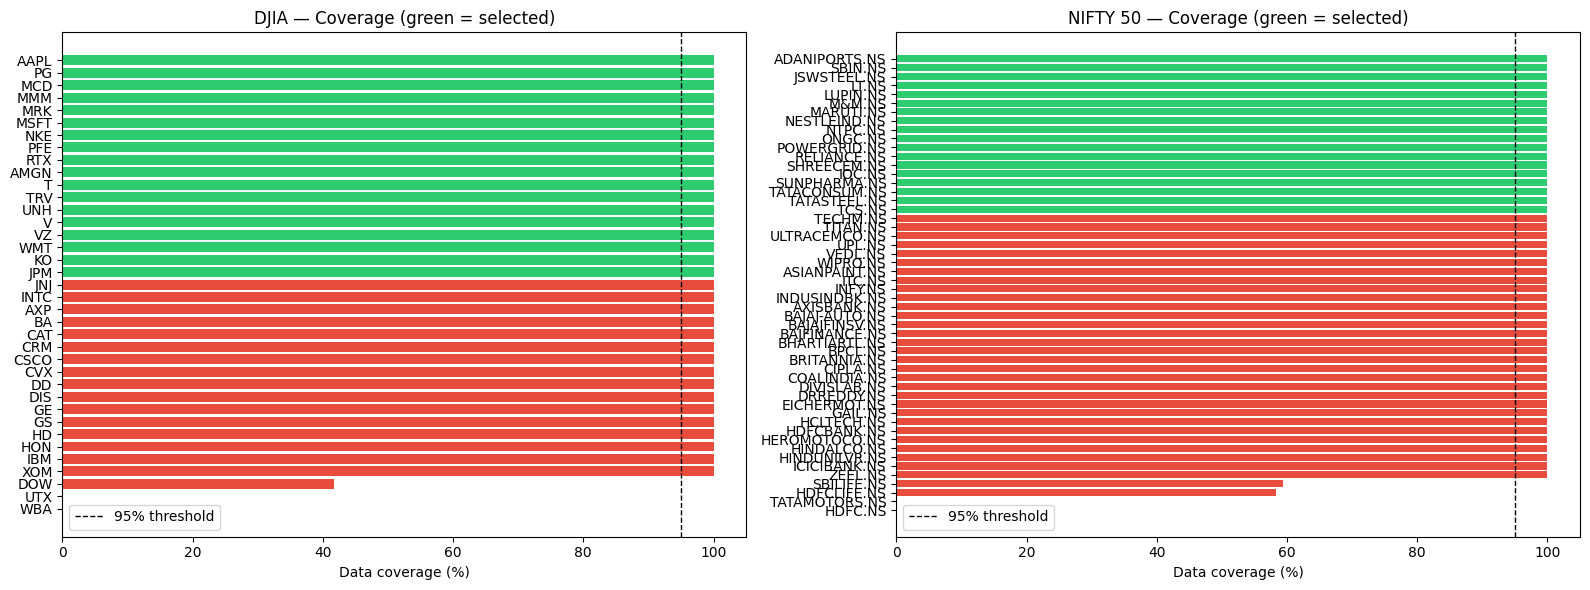

Coverage chart saved.


In [22]:
# ── Visualise coverage ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, report, label, final_tickers in [
    (axes[0], djia_report,  'DJIA',     DJIA_FINAL),
    (axes[1], nifty_report, 'NIFTY 50', NIFTY_FINAL),
]:
    colors = ['#2ecc71' if t in final_tickers else '#e74c3c'
              for t in report['Ticker']]
    ax.barh(report['Ticker'], report['Coverage_%'], color=colors)
    ax.axvline(95, color='black', linestyle='--', linewidth=1, label='95% threshold')
    ax.set_xlabel('Data coverage (%)')
    ax.set_title(f'{label} — Coverage (green = selected)')
    ax.invert_yaxis()
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'stock_coverage.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Coverage chart saved.')

## 4. Download Final Data for Selected Stocks

In [23]:
# ── Extract final price series from already-downloaded data ───────────────────
djia_prices  = djia_all_prices[DJIA_FINAL].copy()
nifty_prices = nifty_all_prices[NIFTY_FINAL].copy()

# Rename columns to S1..S18 (paper notation) + keep a key
def label_stocks(prices, tickers, name_map):
    label_map  = {t: f'S{i+1}' for i, t in enumerate(tickers)}
    reverse    = {f'S{i+1}': (t, name_map.get(t, t)) for i, t in enumerate(tickers)}
    prices_lab = prices.rename(columns=label_map)
    return prices_lab, reverse

djia_prices_lab,  djia_key  = label_stocks(djia_prices,  DJIA_FINAL,  DJIA_CANDIDATES)
nifty_prices_lab, nifty_key = label_stocks(nifty_prices, NIFTY_FINAL, NIFTY_CANDIDATES)

print('DJIA stock key (label → ticker, name):')
for k, v in djia_key.items():
    print(f'  {k}: {v[0]:<10} {v[1]}')

print('\nNIFTY 50 stock key (label → ticker, name):')
for k, v in nifty_key.items():
    print(f'  {k}: {v[0]:<22} {v[1]}')

DJIA stock key (label → ticker, name):
  S1: AAPL       Apple
  S2: PG         Procter & Gamble
  S3: MCD        McDonald's
  S4: MMM        3M
  S5: MRK        Merck
  S6: MSFT       Microsoft
  S7: NKE        Nike
  S8: PFE        Pfizer
  S9: RTX        Raytheon Technologies
  S10: AMGN       Amgen
  S11: T          AT&T
  S12: TRV        Travelers
  S13: UNH        UnitedHealth
  S14: V          Visa
  S15: VZ         Verizon
  S16: WMT        Walmart
  S17: KO         Coca-Cola
  S18: JPM        JPMorgan Chase

NIFTY 50 stock key (label → ticker, name):
  S1: ADANIPORTS.NS          Adani Ports
  S2: SBIN.NS                State Bank of India
  S3: JSWSTEEL.NS            JSW Steel
  S4: LT.NS                  Larsen & Toubro
  S5: LUPIN.NS               Lupin
  S6: M&M.NS                 Mahindra & Mahindra
  S7: MARUTI.NS              Maruti Suzuki
  S8: NESTLEIND.NS           Nestle India
  S9: NTPC.NS                NTPC
  S10: ONGC.NS                ONGC
  S11: POWERGRID.NS    

In [24]:
# ── Missing value check ───────────────────────────────────────────────────────
def check_missing(prices, label):
    window = prices[(prices.index >= TRAIN_START) & (prices.index <= TEST_END)]
    missing = window.isnull().sum()
    if missing.sum() == 0:
        print(f'[OK] {label}: zero missing values in the full window.')
    else:
        print(f'[WARN] {label}: missing values detected:')
        print(missing[missing > 0])
    return window

djia_window  = check_missing(djia_prices_lab,  'DJIA')
nifty_window = check_missing(nifty_prices_lab, 'NIFTY 50')

[OK] DJIA: zero missing values in the full window.
[OK] NIFTY 50: zero missing values in the full window.


## 5. Compute Monthly Returns

Paper formula (Eq. 13–14):  
`r_ti = (p_(t+1)i − p_ti) / p_ti`  
Returns are scaled × 100 (percentage points), as in Eq. 14.

In [25]:
def compute_returns(prices: pd.DataFrame) -> pd.DataFrame:
    """Simple period return × 100 as in the paper."""
    return prices.pct_change().dropna() * 100

djia_returns  = compute_returns(djia_prices_lab)
nifty_returns = compute_returns(nifty_prices_lab)

# Restrict to July 2014 – June 2022
djia_returns  = djia_returns[(djia_returns.index  >= TRAIN_START) & (djia_returns.index  <= TEST_END)]
nifty_returns = nifty_returns[(nifty_returns.index >= TRAIN_START) & (nifty_returns.index <= TEST_END)]

print(f'DJIA returns  shape: {djia_returns.shape}   (expected 96 × 18)')
print(f'NIFTY returns shape: {nifty_returns.shape}  (expected 96 × 18)')

DJIA returns  shape: (96, 18)   (expected 96 × 18)
NIFTY returns shape: (96, 18)  (expected 96 × 18)


## 6. Train / Test Split

In [26]:
def train_test_split(returns: pd.DataFrame):
    idx   = returns.index
    train = returns[(idx >= TRAIN_START) & (idx <= TRAIN_END)]
    test  = returns[(idx >= TEST_START)  & (idx <= TEST_END)]
    return train, test

djia_train,  djia_test  = train_test_split(djia_returns)
nifty_train, nifty_test = train_test_split(nifty_returns)

for label, train, test in [('DJIA', djia_train, djia_test),
                             ('NIFTY', nifty_train, nifty_test)]:
    print(f'{label}  train: {train.shape}  {train.index[0].date()} → {train.index[-1].date()}')
    print(f'{label}  test : {test.shape}   {test.index[0].date()}  → {test.index[-1].date()}')

DJIA  train: (72, 18)  2014-07-31 → 2020-06-30
DJIA  test : (24, 18)   2020-07-31  → 2022-06-30
NIFTY  train: (72, 18)  2014-07-31 → 2020-06-30
NIFTY  test : (24, 18)   2020-07-31  → 2022-06-30


## 7. Save All Data to `./data/`

In [27]:
def save(df, filename):
    path = os.path.join(DATA_DIR, filename)
    df.to_csv(path)
    print(f'Saved  {filename:<45}  {df.shape}')

# Prices
save(djia_prices_lab,  'nyse_prices.csv')
save(nifty_prices_lab, 'nse_prices.csv')

# Full returns
save(djia_returns,  'nyse_returns.csv')
save(nifty_returns, 'nse_returns.csv')

# Train / test
save(djia_train,  'nyse_train.csv')
save(djia_test,   'nyse_test.csv')
save(nifty_train, 'nse_train.csv')
save(nifty_test,  'nse_test.csv')

# Stock key files (mapping S1..S18 to tickers)
import json
with open(os.path.join(DATA_DIR, 'djia_stock_key.json'),  'w') as f:
    json.dump(djia_key,  f, indent=2)
with open(os.path.join(DATA_DIR, 'nifty_stock_key.json'), 'w') as f:
    json.dump(nifty_key, f, indent=2)
print('Saved  djia_stock_key.json + nifty_stock_key.json')

# Completeness reports
djia_report.to_csv( os.path.join(DATA_DIR, 'djia_completeness_report.csv'),  index=False)
nifty_report.to_csv(os.path.join(DATA_DIR, 'nifty_completeness_report.csv'), index=False)
print('Saved  completeness reports')

Saved  nyse_prices.csv                                (98, 18)
Saved  nse_prices.csv                                 (98, 18)
Saved  nyse_returns.csv                               (96, 18)
Saved  nse_returns.csv                                (96, 18)
Saved  nyse_train.csv                                 (72, 18)
Saved  nyse_test.csv                                  (24, 18)
Saved  nse_train.csv                                  (72, 18)
Saved  nse_test.csv                                   (24, 18)
Saved  djia_stock_key.json + nifty_stock_key.json
Saved  completeness reports


## 8. Summary Statistics & Sanity Checks

In [28]:
# ── Descriptive stats for training data ──────────────────────────────────────
print('═' * 60)
print('DJIA — Training return stats (monthly %, Jul 2014 – Jun 2020)')
print('═' * 60)
print(djia_train.describe().round(3))

print('\n' + '═' * 60)
print('NIFTY — Training return stats (monthly %, Jul 2014 – Jun 2020)')
print('═' * 60)
print(nifty_train.describe().round(3))

════════════════════════════════════════════════════════════
DJIA — Training return stats (monthly %, Jul 2014 – Jun 2020)
════════════════════════════════════════════════════════════
Ticker       S1      S2       S3       S4       S5       S6       S7       S8  \
count   72.0000 72.0000  72.0000  72.0000  72.0000  72.0000  72.0000  72.0000   
mean     2.3530  0.9290   1.1960   0.5010   0.7820   2.5810   1.5670   0.5780   
std      7.7450  4.1260   4.8390   5.5180   4.9770   6.0490   5.9580   5.3380   
min    -18.4040 -8.7540 -14.3100 -15.7040 -13.3400 -13.0250 -12.1710 -13.5220   
25%     -2.6840 -1.4530  -1.1910  -2.1730  -2.0930  -0.7120  -1.9590  -2.3680   
50%      3.0720  1.7560   0.9400   0.7490   0.6180   2.5750   0.8960   0.8340   
75%      7.6560  3.7560   4.0650   3.9000   4.3320   5.6980   5.5390   3.3360   
max     19.6230  8.3470  13.9250  11.2890  11.6230  19.6260  13.9010  17.5250   

Ticker       S9      S10      S11      S12      S13      S14      S15  \
count   72.00

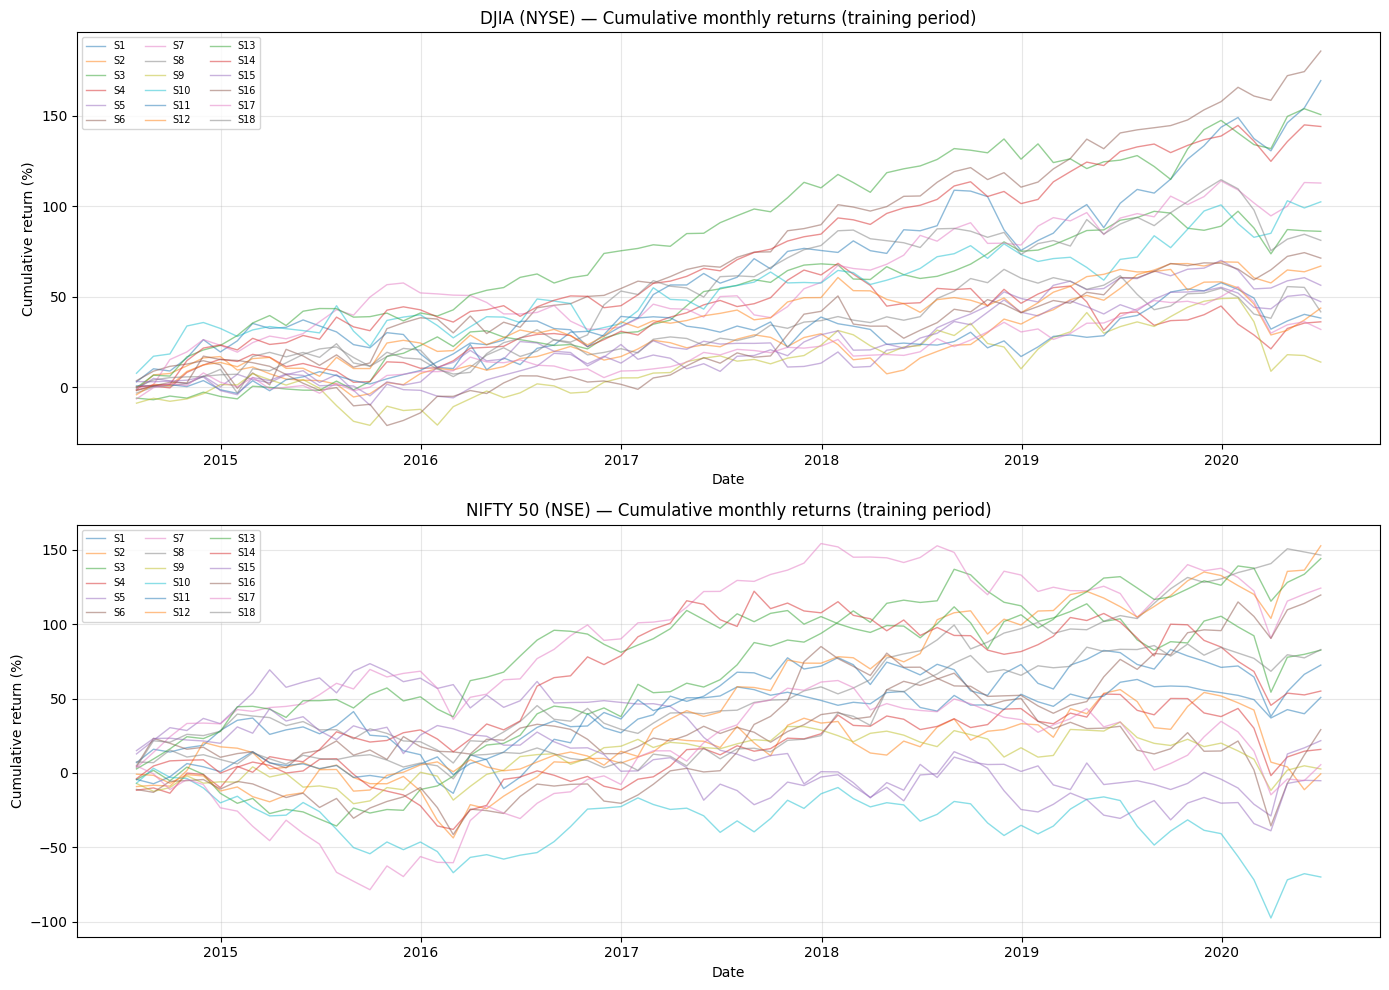

In [29]:
# ── Distribution plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, train, label in [(axes[0], djia_train, 'DJIA (NYSE)'),
                          (axes[1], nifty_train, 'NIFTY 50 (NSE)')]:
    for col in train.columns:
        ax.plot(train.index, train[col].cumsum(), alpha=0.5, linewidth=1)
    ax.set_title(f'{label} — Cumulative monthly returns (training period)')
    ax.set_ylabel('Cumulative return (%)')
    ax.set_xlabel('Date')
    ax.legend(train.columns, loc='upper left', fontsize=7, ncol=3)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'cumulative_returns_training.png'), dpi=150, bbox_inches='tight')
plt.show()

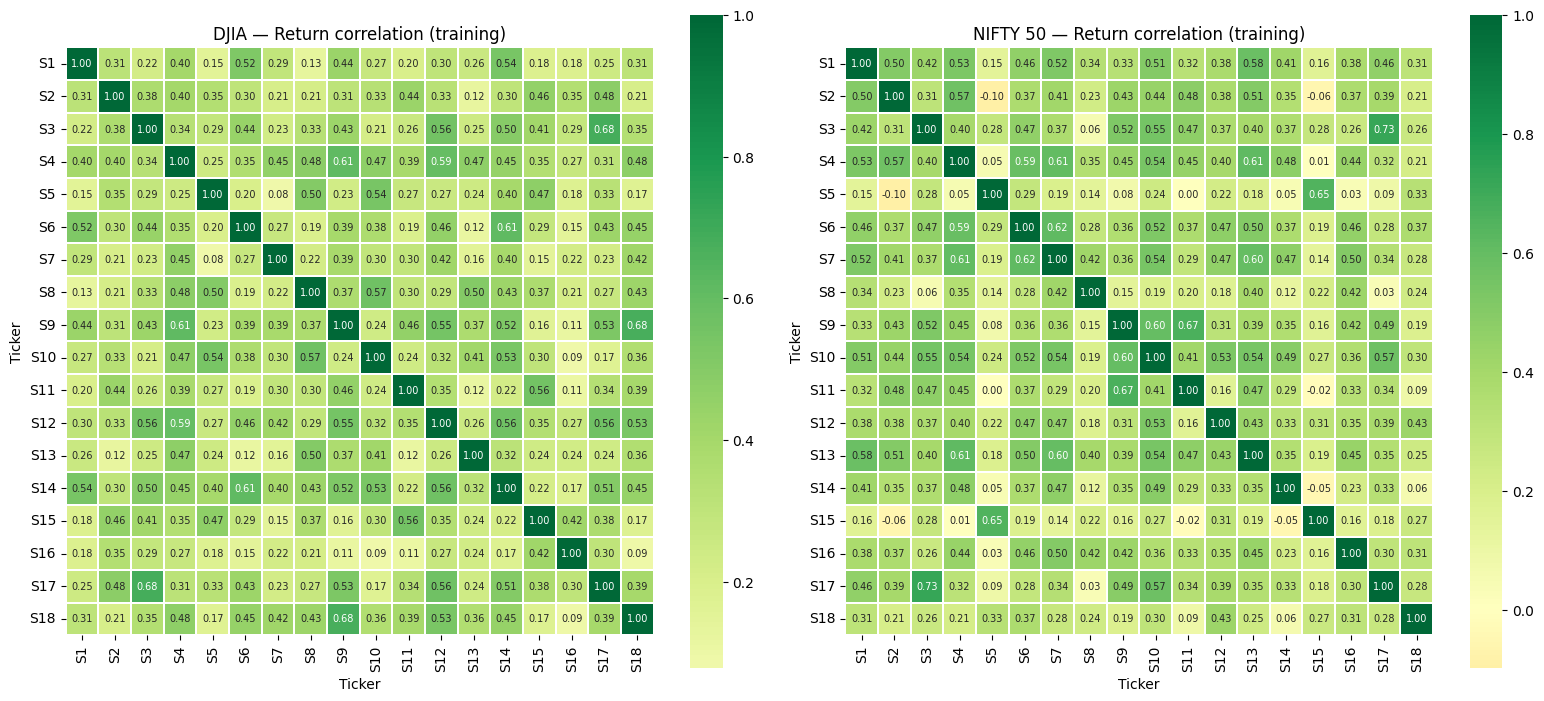

In [30]:
# ── Correlation heatmaps ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, train, label in [(axes[0], djia_train, 'DJIA'),
                          (axes[1], nifty_train, 'NIFTY 50')]:
    corr = train.corr()
    sns.heatmap(corr, ax=ax, cmap='RdYlGn', center=0,
                annot=True, fmt='.2f', annot_kws={'size': 7},
                linewidths=0.3, square=True)
    ax.set_title(f'{label} — Return correlation (training)')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'correlation_heatmaps.png'), dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# ── Final confirmation ────────────────────────────────────────────────────────
print('\n' + '═'*55)
print('DATA COLLECTION COMPLETE')
print('═'*55)
print(f'Output folder : {DATA_DIR}')
print()
files = sorted(os.listdir(DATA_DIR))
for f in files:
    path = os.path.join(DATA_DIR, f)
    size_kb = os.path.getsize(path) / 1024
    print(f'  {f:<45}  {size_kb:6.1f} KB')

print()
print('Next step → implement CTFN fitting + MOGA in next notebook.')


═══════════════════════════════════════════════════════
DATA COLLECTION COMPLETE
═══════════════════════════════════════════════════════
Output folder : /Users/ppsfolder/Cowork Playground/Quant/Project/data

  correlation_heatmaps.png                        392.4 KB
  cumulative_returns_training.png                 734.8 KB
  djia_completeness_report.csv                      1.9 KB
  djia_stock_key.json                               0.7 KB
  nifty_completeness_report.csv                     3.2 KB
  nifty_stock_key.json                              0.9 KB
  nse_prices.csv                                   31.7 KB
  nse_returns.csv                                  33.0 KB
  nse_test.csv                                      8.3 KB
  nse_train.csv                                    24.8 KB
  nyse_prices.csv                                  32.7 KB
  nyse_returns.csv                                 33.0 KB
  nyse_test.csv                                     8.3 KB
  nyse_train.csv        

---
## Hyperparameter Reference

All defaults to use in the optimisation notebook:

| Parameter | Value | Source |
|---|---|---|
| `n` (portfolio size) | 18 | Paper Table 3 |
| `κ` (cardinality) | 5 | Paper Table 3 |
| `l_i` (min weight) | 0.08 | Paper Table 3 |
| `u_i` (max weight) | 0.30 | Paper Table 3 |
| CVaR confidence `p` | 0.95 | Paper Table 3 |
| Population `P_N` | 180 | Paper Table 3 |
| Generations `G_max` | 2000 | Paper Table 3 |
| Runs `R_max` | 30 | Paper Table 3 |
| Crossover prob `cp` | grid {0.6, 0.7, 0.8} | Paper Remark 11 |
| Mutation prob `mp` | grid {0.2, 0.3, 0.4} | Paper Remark 11 |
| CCBEX `λ` | **1.0** | Default from BEX paper [72] |
| Power mutation index `p_mut` | **5** | Default from Deep & Thakur [73] |
| K-medoids `K` | **25** | Implied by result tables |
| `b1` | `min(returns, Q3)` | Paper Section 4.1 Step IV |
| `b2` | `Q50` | Paper Section 4.1 Step IV |
| `b3` | `Q97` | Paper Section 4.1 Step IV |
| `k` (CTFN shape) | Fixed per solution, formula using Q20/Q80 | Paper Section 4.1 Step V |
| Min monthly return filter | 2.0% | Paper Section 5.1 |
| Skewness filter | S ≥ 0 | Paper Table 3 |